# Разработка AI-агентов на основе LLM

## Введение

AI-агенты представляют собой качественный скачок в автоматизации интеллектуального труда. В отличие от чат-ботов, задача которых ограничивается поддержанием диалога, агенты проектируются как **универсальные решатели проблем** (General Problem Solvers), способные достигать поставленных целей в условиях неопределенности.

Ключевым отличием является наличие **агентности** (agency) — способности инициировать действия, а не просто реагировать. Это становится возможным благодаря интеграции модели с модулями памяти, планирования и интерфейсами прикладного программирования (API).

> Агентный подход превращает LLM в **центральный управляющий элемент** системы, способный воспринимать динамическую среду, планировать последовательности действий, использовать внешние инструменты и рефлексировать над собственными ошибками


## Архитектура агентов

Центральной концепцией в разработке автономных систем является когнитивная архитектура, которая определяет, как агент обрабатывает информацию, хранит опыт и принимает решения. На практике доминирует подход, при котором LLM управляет тремя периферийными модулями:
- планированием (Planning)
- памятью (Memory)
- использованием Инструментов (Tool Use)

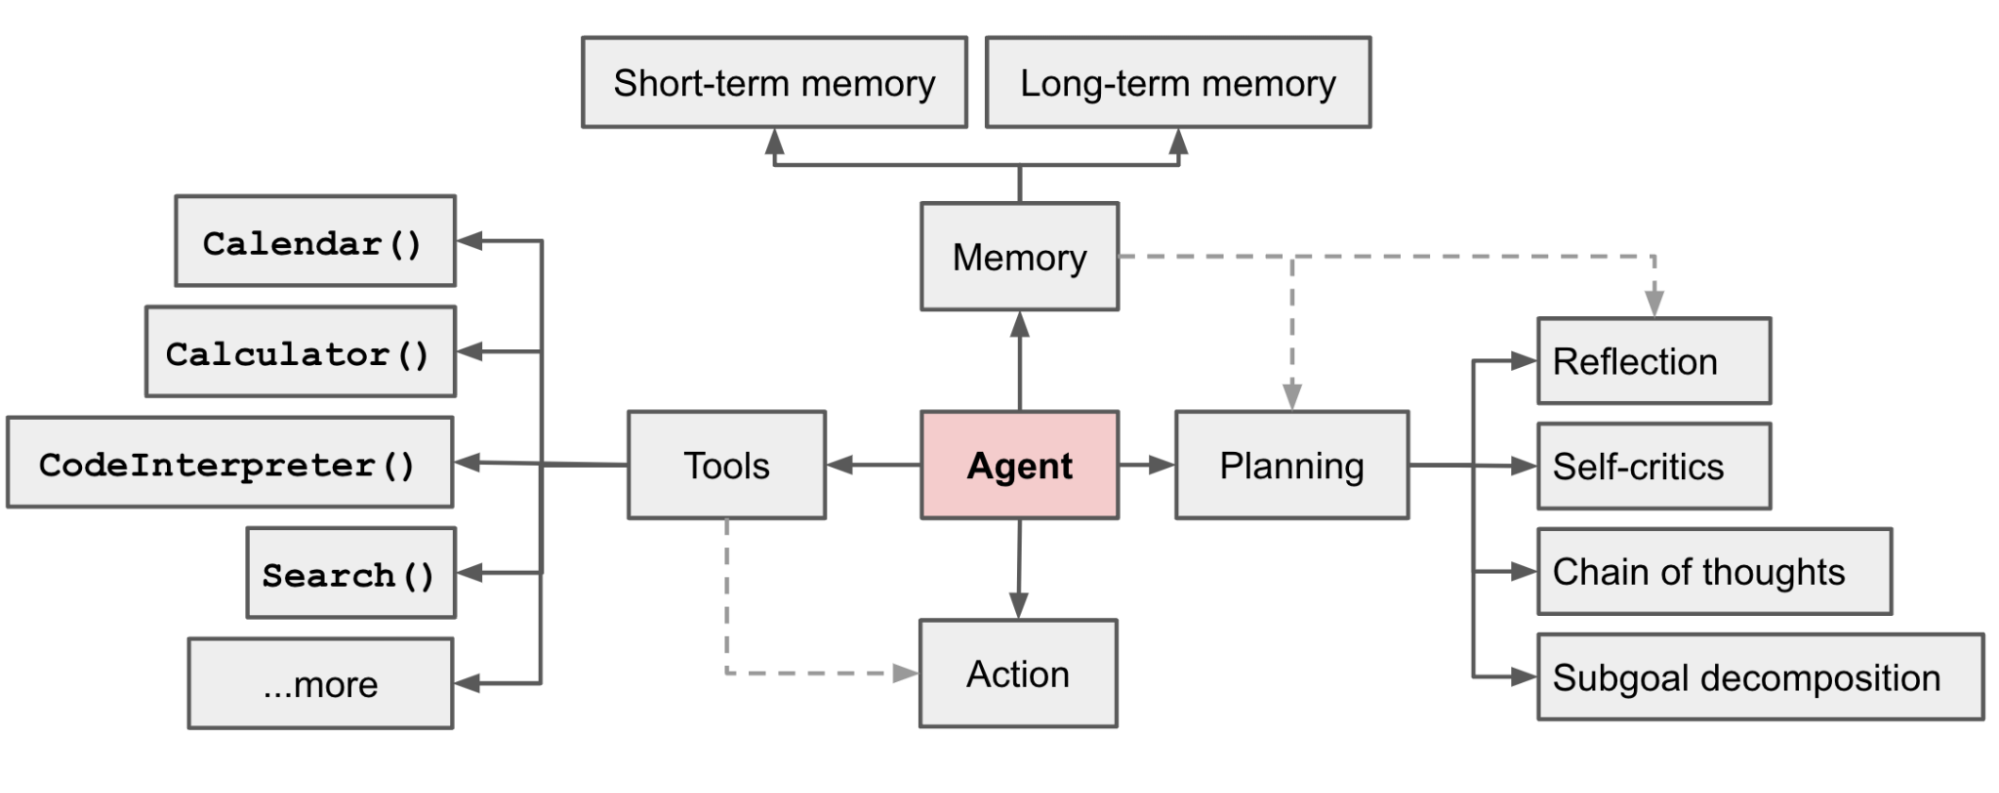

### Планирование

Планирование является фундаментальным компонентом, позволяющим агентам справляться со сложными, многоступенчатыми задачами, решение которых невозможно в рамках одного шага инференса. Этот модуль отвечает за трансформацию высокоуровневых целей в **последовательность исполняемых действий**.

Эффективное планирование часто требует разбиения задачи на подзадачи. Это позволяет снизить когнитивную нагрузку на модель на каждом этапе и повысить точность выполнения. Одним из наиболее перспективных подходов, дополняющих классические методы рассуждений, является Least-to-Most Prompting (LtM). В отличие от стандартного Chain of Thought (CoT), который генерирует цепочку рассуждений линейно, LtM реализует двухэтапный процесс:   

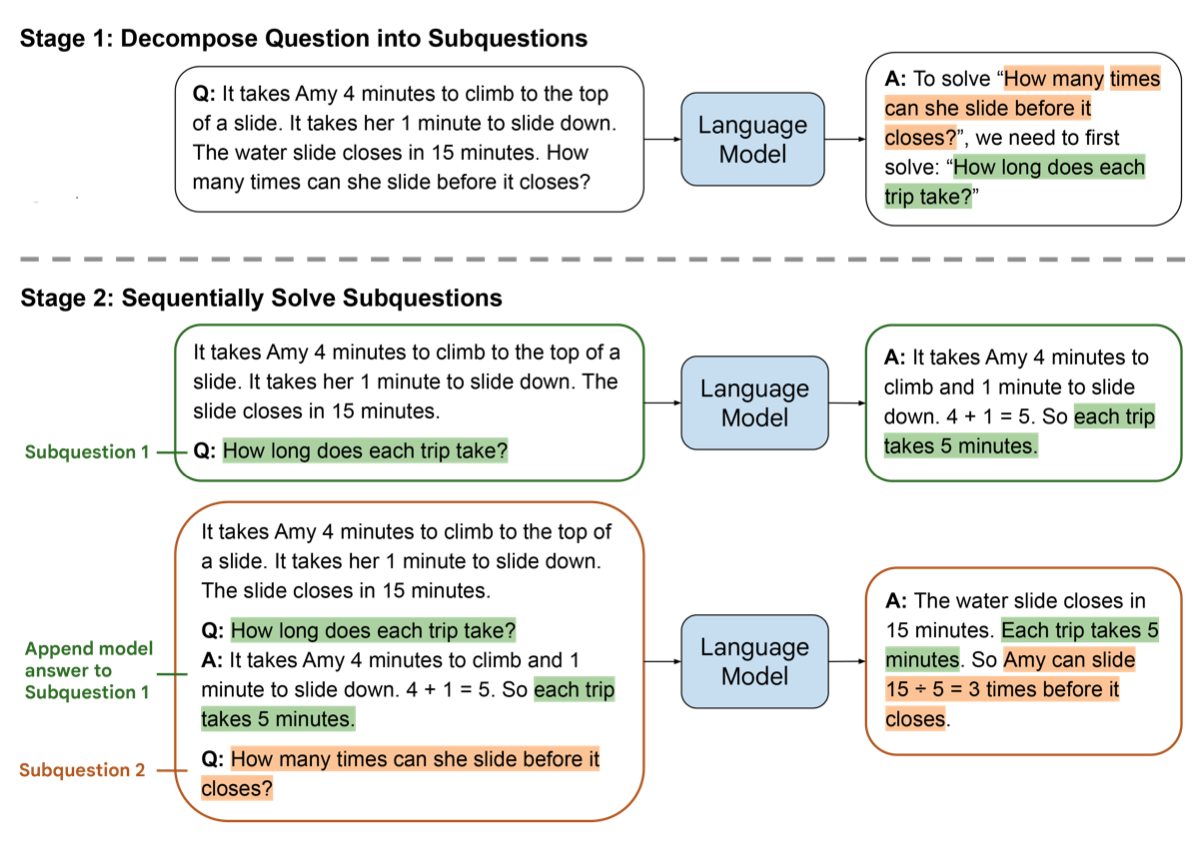


> Критически важно, что решение каждой предыдущей подзадачи передается в контекст (prompt) для решения следующей. Это создает **динамическую цепочку контекста**, где каждое последующее действие опирается на результат предыдущего. 

Вторым аспектом планирования является способность к самокоррекции. В реальных сценариях планы часто сталкиваются с непредвиденными препятствиями. Механизм **Self-Reflection** позволяет агенту анализировать историю своих действий, выявлять ошибки и корректировать стратегию без вмешательства человека. Это реализуется через отдельные промпты, которые просят модель оценить качество полученного результата. Рефлексия превращает процесс выполнения задачи из линейного в циклический, где неудача становится источником обучающего сигнала. 

### Память

В архитектуре LLM-агентов выделяют два основных типа памяти, аналогичных человеческим когнитивным процессам.   

**Кратковременная память (Short-term Memory)**

Реализуется через контекстное окно модели (in-context learning). Это оперативное пространство, где хранится текущая траектория рассуждений, последние наблюдения и инструкции. Ограниченность объема контекстного окна и квадратичная сложность внимания делают невозможным хранение всей истории взаимодействия в кратковременной памяти.

**Долговременная память (Long-term Memory)**

Внешнее хранилище, позволяющее сохранять и извлекать информацию неограниченное время. Технически это реализуется через векторные базы данных (Vector Stores), такие как Pinecone, Milvus или Chroma. Текстовая информация преобразуется в векторные представления и сохраняется. При необходимости агент выполняет поиск ближайших соседей для извлечения релевантного контекста.

Критическим элементом долговременной памяти является **функция извлечения**(Retrieval Function). Простого семантического поиска часто недостаточно для моделирования правдоподобного поведения или решения сложных задач. Была предложена сложная формула оценки релевантности, которая определяет, какие воспоминания попадут в контекст модели. 

Оценка рассчитывается как взвешенная сумма трех компонентов 7:

$$Score = \alpha_{recency} \cdot R + \alpha_{importance} \cdot I + \alpha_{relevance} \cdot Rel$$

**Recency (R - Недавность)**

Отражает принцип работы человеческой памяти, где недавние события доступнее для воспоминания. Реализуется как функция экспоненциального затухания: $R = 0.995^{hours\_since\_last\_access}$. Это гарантирует, что агент не застрянет в старых контекстах.

**Importance (I - Важность)**

Важность присваивается самой LLM в момент записи памяти: модель просят оценить событие по шкале от 1 до 10. Это добавляет семантическую фильтрацию на этапе записи.

**Relevance (Rel - Релевантность)**

Классическая метрика косинусного сходства между вектором запроса (текущей ситуации) и вектором сохраненного воспоминания.

> Все компоненты нормализуются с использованием min-max скалирования перед суммированием

### Использование инструментов

Инструменты могут включать поисковые движки (Google, Yandex), интерпретаторы кода (Python), математические решатели (Wolfram Alpha) и **любые другие API** (включая MCP).

Важным этапом в развитии этой области стала **модель Toolformer** ([оригинальное исследование, 2023](https://arxiv.org/abs/2302.04761)), которая продемонстрировала, что LLM могут самостоятельно учиться использовать инструменты без большого объема размеченных данных. Toolformer обучается в режиме self-supervised learning:
- модель генерирует потенциальные вызовы API в тексте
- вызовы исполняются, и результаты подставляются в текст.
- если добавление результата API снижает перплексию (perplexity) модели при предсказании следующих токенов, этот пример сохраняется для дообучения (fine-tuning)

> Таким образом, модель учится не просто вызывать API, а делать это только тогда, когда это действительно полезно для предсказания будущего текста

Набор инструментов Toolformer включал калькулятор, поисковик Википедии, календарь и переводчик. 

> Это позволяет агентам преодолевать ограничения замороженных знаний и выполнять точные операции, недоступные для стохастических нейросетей.


## ReAct и Reflexion

### Синергия подходов

[Представлена в исследовании 2022 года](https://arxiv.org/abs/2210.03629). **ReAct** преодолевает разрыв между двумя изолированными ранее подходами: рассуждениями и действиями.

**Reasoning-only (только рассуждения)**
Модели использовали CoT и другие подходы для генерации цепочек мыслей. Это улучшало решение логических задач, но страдало от проблемы галлюцинаций и распространения ошибок (error propagation), так как модель не имела доступа к внешнему миру для проверки фактов.

**Acting-only (только действия)**

Модели генерировали действия (например, команды для веб-навигации), но не объясняли, почему они это делают. Без рассуждений агенты часто совершали хаотичные или ошибочные действия, не имея возможности скорректировать долгосрочный план.

Формально, пространство действий агента $\hat{A}$ расширяется за счет включения пространства языковых действий $L$ (мысли/рассуждения): $\hat{A} = A \cup L$, где $A$ — множество физических действий или вызовов API.

Работа агента строится как итеративный процесс генерации траектории $\tau = (o_1, \hat{a}_1, o_2, \hat{a}_2, \dots)$, где $o_t$ — наблюдение, а $\hat{a}_t$ — действие.

Алгоритм функционирует следующим образом:

**Получение наблюдения ($o_t$)**
Агент воспринимает состояние среды (результат предыдущего поискового запроса).

**Генерация Мысли (Thought, $\hat{a}_t \in L$)**
Агент генерирует рассуждение на естественном языке. Это действие не меняет состояние внешней среды, но обновляет внутренний контекст $c_{t+1} = (c_t, \hat{a}_t)$. Мысль может содержать декомпозицию задачи, анализ полученной информации ("В этом документе нет ответа на вопрос, нужно искать по другому ключевому слову") или планирование следующего шага.

**Генерация Действия (Action, $\hat{a}_t \in A$)**
Агент формирует конкретную команду для инструмента (искать в Google что-то).

**Исполнение и Наблюдение**
Среда исполняет команду и возвращает результат ($o_{t+1}$), который подается на вход агенту на следующем шаге.

### Вербальное подкрепление

ReAct не обладает механизмом обучения на ошибках между сессиями без обновления весов. **Фреймворк Reflexion** ([оригинальное исследование 2023 года](https://arxiv.org/pdf/2303.11366)) решает эту проблему, внедряя механизм вербального обучения с подкреплением (Verbal Reinforcement Learning). Агент учится, сохраняя текстовые описания своих ошибок в кратковременной памяти (контексте) для следующих попыток.

> Традиционное обучение с подкреплением требует тысяч итераций и обновления весов нейросети на основе скалярной награды. Reflexion заменяет обновление весов на обновление кратковременной памяти, а скалярную награду — на текстовую обратную связь. То есть это не тот самый RL :)


Система Reflexion состоит из трех основных моделей:   
- Actor (Исполнитель): ReAct-агент, который генерирует траектории действий и мыслей

- Evaluator (Оценщик): компонент, оценивающий качество результата; в задачах кодинга может быть компилятор или набор тестов; в задачах рассуждения — другая LLM

- Self-Reflection (Модель рефлексии): LLM, которая анализирует неудачную траекторию и генерирует вербальный урок

Алгоритм работает в цикле:

**Инициализация**
Пустая память $mem$, счетчик попыток $t=0$.

**Цикл (While)**
Пока Evaluator не вернет "Успех" и $t < max\_trials$

**Генерация траектории**
Actor пытается решить задачу, учитывая текущее содержимое $mem$.

**Оценка**
Evaluator проверяет результат.

**Рефлексия**
Если результат неудовлетворительный, Self-Reflection модель анализирует траекторию и генерирует описание ошибки ("Я использовал неверный метод списка в Python, нужно использовать `.append()`").

**Обновление памяти**
Это описание ошибки добавляется в $mem$.

**Повтор**
В следующей итерации Actor видит это описание в своем контексте и избегает повторения ошибки.

## Актуальные вызовы

> Несмотря на значительный прогресс в области NLP в последние годы создание надежных AI-агентов остается **сложной инженерной задачей**

**Зацикливание**

Агент может зациклиться, повторяя одно и то же действие (`search("погода")`), если результат действия не меняет его внутреннее состояние достаточно для перехода к следующему шагу или если он не может корректно интерпретировать вывод инструмента. Современные фреймворки (`LangGraph`) вводят жесткие ограничения на количество итераций (`max_iterations` или `max_round`).

**Галлюцинации при вызове инструментов**

Агенты могут галлюцинировать не только факты, но и вызовы инструментов. Это проявляется в вызове несуществующих функций или передаче аргументов, не соответствующих сигнатуре функции (часто актуально при работе с MCP-серверами; можно вспомнить выполнение некорректных команд в терминале при вайб-коддинге). Как вариант решения: использование `Pydantic` для строгой валидации входных данных инструментов. Если агент передает неверные аргументы, `Pydantic` выбрасывает ошибку валидации, которая возвращается агенту как наблюдение.

**Переполнение контекста**

Длительные сессии приводят к переполнению контекстного окна. Чем больше шагов делает агент, тем больше промежуточных мыслей и ошибок накапливается в истории. Это не только увеличивает стоимость LLM API (оплата токенов), но и снижает качество работы модели. Эффективные стратегии управления памятью (сжатие старых сообщений с помощью суммаризации, сброс данных в долговременную память) являются обязательным элементом агентных систем.

---

## Практическая часть

[Примеры ИИ-агентов на LangChain с GigaChat](https://disk.yandex.ru/d/3L8G4zp3pVEAaQ)